### Flagging vendor invoice for manual review 
predict whether a vendor invoice should be flagged for manual approval based on abnormal cost,freight or delivery pattern ,in order to reduce the financial risk , improve operational efficiency and prioritize human review where it is required 

This flagging system allows enables finance teams to focus attention on high risk invoices while allowing low risk invoices to procced automatically 
As manual review is time consuming and does not scale with transaction volume

In [53]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
conn = sqlite3.connect('/Users/prashant/Invoice Intelligence/data/inventory.db')

In [6]:
tables = pd.read_sql_query('Select name from sqlite_master where type ="table" ',conn)
for table in tables['name']:
    print(f"table name is {table}")
    df = pd.read_sql_query(f"select * from {table} limit 5 ",conn)
    display(df)

table name is purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


table name is purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


table name is vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


table name is begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


table name is end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [11]:
purchace_agg_df = pd.read_sql_query("""select p.PONumber,
                  count(distinct p.Brand) as total_brands,
                  sum(p.Quantity) as total_items_quantity,
                  sum(p.Dollars) as total_item_dollars,
                  avg(julianday(p.ReceivingDate) - julianday(p.PODate)) as avg_recieving_delay
                  from purchases p group by p.PONumber""",conn)

per purchase order find total brands , total quantity of items , total cost(Dollar)

In [12]:
purchace_agg_df.head()

,PONumber,total_brands,total_items_quantity,total_item_dollars,avg_recieving_delay
0,8106,81,10100,137483.78,12.614130
1,8107,2,24,348.72,12.500000
2,8108,165,8466,60281.13,12.632479
3,8109,23,2246,14298.09,12.626866
4,8110,183,8086,56493.23,12.695271


In [15]:
purchace_agg_df.loc[purchace_agg_df['PONumber']==8137,['PONumber','total_items_quantity','total_item_dollars']]

,PONumber,total_items_quantity,total_item_dollars
26,8137,15,140.55


vendor invoice table is already grouped and aggregated by PONumber so no need to do that there all PONumbers in it are unique

In [27]:
vi = pd.read_sql_query('select * from vendor_invoice',conn)
vi['PONumber'].nunique()==vi.shape[0]

True

In [30]:
purchace_agg_df.shape[0] == vi.shape[0]

True

In [ ]:
df = pd.read_sql_query(""" 
        WITH  purchase_agg AS (
                SELECT p.PONumber,
                 COUNT(DISTINCT p.Brand) AS total_brands,
                  SUM(p.Quantity) AS total_item_quantity,
                  SUM(p.Dollars) AS total_item_dollars,
                  AVG(julianday(p.ReceivingDate) - julianday(p.PODate)) AS avg_receiving_delay
                FROM purchases p GROUP BY p.PONumber
        )
        SELECT
        vi.PONumber,
        vi.Quantity AS  
        vi.Dollars AS invoice_dollars,
        vi.Freight,
        (julianday(vi.InvoiceDate)-julianday(vi.PODate)) AS days_po_to_invoice,
        (julianday(vi.PayDate)-julianday(vi.InvoiceDate)) AS days_to_pay,
        pa.total_brands,
        pa.total_item_quantity,
        pa.total_item_dollars,
        pa.avg_receiving_delay
        FROM vendor_invoice vi
        LEFT JOIN purchase_agg pa ON
        vi.PONumber = pa.PONumber
 """,conn)

In [48]:
df.isnull().sum()

PONumber               0
invoice_quantity       0
invoice_dollars        0
Freight                0
days_po_to_invoice     0
days_to_pay            0
total_brands           0
total_item_quantity    0
total_item_dollars     0
avg_receiving_delay    0
dtype: int64

In [49]:
df.dtypes

PONumber                 int64
invoice_quantity         int64
invoice_dollars        float64
Freight                float64
days_po_to_invoice     float64
days_to_pay            float64
total_brands             int64
total_item_quantity      int64
total_item_dollars     float64
avg_receiving_delay    float64
dtype: object

for training phase manually Deciding label for risk as 1 when 
<ul>
    <li> total invoice dollars > total_item_dollars+5 </li>
    <li> Abnormally high delay  </li>
</ul>

In [50]:
def create_invoice_risk_label(row):
    if (abs(row['invoice_dollars']-row['total_item_dollars'])>5):
        return 1
    if (row['avg_receiving_delay']>10):
        return 1
    return 0

df['flag_invoice'] = df.apply(create_invoice_risk_label,axis=1)
df['flag_invoice'].value_counts()

flag_invoice
0    3693
1    1850
Name: count, dtype: int64

In [51]:
df.corr()

,PONumber,invoice_quantity,invoice_dollars,Freight,days_po_to_invoice,days_to_pay,total_brands,total_item_quantity,total_item_dollars,avg_receiving_delay,flag_invoice
PONumber,1.000000,0.049230,0.058917,0.043617,-0.002234,0.012558,0.013423,0.049442,0.059221,-0.042362,0.564946
invoice_quantity,0.049230,1.000000,0.963831,0.946550,0.000526,0.022284,0.566394,0.706117,0.668171,0.000519,0.032783
invoice_dollars,0.058917,0.963831,1.000000,0.985141,0.001610,0.025661,0.536952,0.667666,0.679537,0.004694,0.037994
Freight,0.043617,0.946550,0.985141,1.000000,0.003265,0.025513,0.536381,0.656616,0.670768,0.015645,0.037759
days_po_to_invoice,-0.002234,0.000526,0.001610,0.003265,1.000000,-0.370432,0.009519,0.005543,0.007931,0.515538,0.183115
days_to_pay,0.012558,0.022284,0.025661,0.025513,-0.370432,1.000000,0.020336,0.016203,0.015610,-0.029403,-0.005289
total_brands,0.013423,0.566394,0.536952,0.536381,0.009519,0.020336,1.000000,0.783825,0.753092,0.000496,0.008961
total_item_quantity,0.049442,0.706117,0.667666,0.656616,0.005543,0.016203,0.783825,1.000000,0.963831,-0.014016,0.032783
total_item_dollars,0.059221,0.668171,0.679537,0.670768,0.007931,0.015610,0.753092,0.963831,1.000000,-0.014251,0.037994
avg_receiving_delay,-0.042362,0.000519,0.004694,0.015645,0.515538,-0.029403,0.000496,-0.014016,-0.014251,1.000000,0.311667


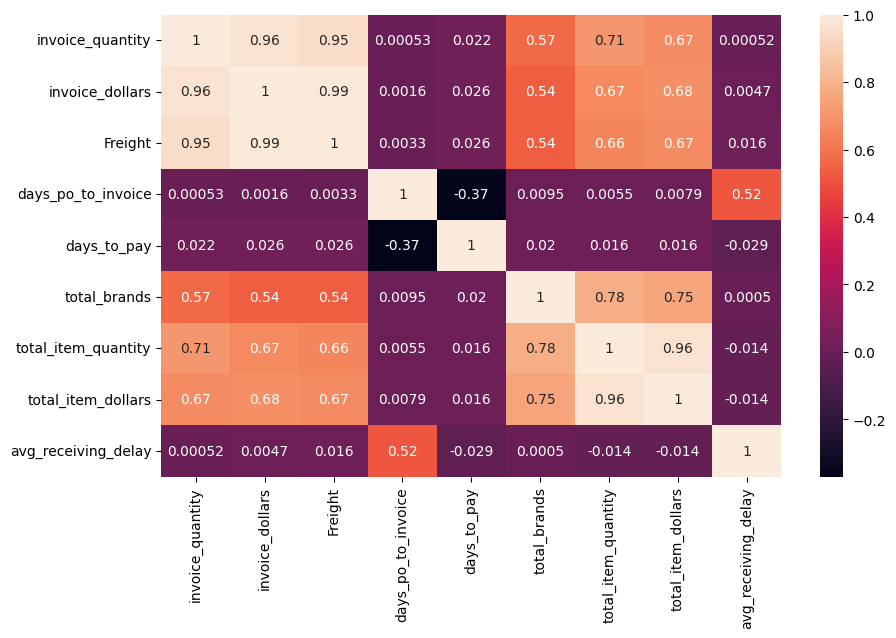

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(df.iloc[:,1:-1].corr(),annot=True)  
plt.show()

In [57]:
flagged = df[df['flag_invoice']==1]
normal = df[df['flag_invoice']==0]

In [82]:
significant_features = []
non_significant_features = [] 
results = []

In [83]:
metrics = ['invoice_quantity','invoice_dollars','Freight','days_po_to_invoice','days_to_pay','total_brands',
           'total_item_quantity','total_item_dollars','avg_receiving_delay']

In [84]:
from scipy.stats import ttest_ind

In [85]:
for m in metrics:
    flagged_mean = flagged[m].mean()
    normal_mean = normal[m].mean()

    t_stat , p_value = ttest_ind(
        flagged[m].dropna(),
        normal[m].dropna(),
        equal_var = False
    )
    if p_value < 0.05:
        significant_features.append(m)
        results.append({"metric":m,"flagged_mean":flagged_mean.round(2),"normal_mean":normal_mean.round(2),"p_mean":p_value.round(3)})
    
    else :
        non_significant_features.append({'metrics':m,"flagged_mean":flagged_mean.round(2),"normal_mean":normal_mean.round(2),"p_mean":p_value.round(3)})

In [86]:
non_significant_features

[{'metrics': 'days_to_pay',
  'flagged_mean': np.float64(35.42),
  'normal_mean': np.float64(35.49),
  'p_mean': np.float64(0.692)},
 {'metrics': 'total_brands',
  'flagged_mean': np.float64(42.29),
  'normal_mean': np.float64(40.82),
  'p_mean': np.float64(0.508)}]

In [88]:
results

[{'metric': 'invoice_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_mean': np.float64(0.021)},
 {'metric': 'invoice_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_mean': np.float64(0.008)},
 {'metric': 'Freight',
  'flagged_mean': np.float64(334.02),
  'normal_mean': np.float64(276.89),
  'p_mean': np.float64(0.008)},
 {'metric': 'days_po_to_invoice',
  'flagged_mean': np.float64(17.23),
  'normal_mean': np.float64(16.02),
  'p_mean': np.float64(0.0)},
 {'metric': 'total_item_quantity',
  'flagged_mean': np.float64(6728.28),
  'normal_mean': np.float64(5723.55),
  'p_mean': np.float64(0.021)},
 {'metric': 'total_item_dollars',
  'flagged_mean': np.float64(65600.61),
  'normal_mean': np.float64(54302.64),
  'p_mean': np.float64(0.008)},
 {'metric': 'avg_receiving_delay',
  'flagged_mean': np.float64(8.47),
  'normal_mean': np.float64(7.27),
  'p_mean': np.float64(0.0)}]

In [90]:
X  = df[['invoice_quantity','invoice_dollars','Freight','total_brands','total_item_quantity','days_po_to_invoice','total_item_dollars']]
Y = df['flag_invoice']

comapany doesn't recieve avg_receiving_delay that's why remove it 
<br>
also there is no significance of days_to_pay using t test

In [91]:
X.describe()

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
count,5543.000000,5.543000e+03,5543.000000,5543.000000,5543.000000,5543.000000,5.543000e+03
mean,6058.880931,5.807338e+04,295.954301,41.312466,6058.880931,16.424499,5.807338e+04
std,14453.338164,1.402340e+05,713.585093,76.940674,14453.338164,3.127282,1.402340e+05
min,1.000000,4.140000e+00,0.020000,1.000000,1.000000,9.000000,4.140000e+00
25%,83.000000,9.678100e+02,5.020000,3.000000,83.000000,14.000000,9.678100e+02
50%,423.000000,4.765450e+03,24.730000,7.000000,423.000000,16.000000,4.765450e+03
75%,5100.500000,4.458718e+04,229.660000,46.000000,5100.500000,19.000000,4.458718e+04
max,141660.000000,1.660436e+06,8468.220000,807.000000,141660.000000,23.000000,1.660436e+06


In [99]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=16)

In [100]:
from sklearn.preprocessing import StandardScaler,MinMaxScaler

In [129]:
ss = MinMaxScaler()
X_train_scaled = pd.DataFrame(ss.fit_transform(X_train),columns=X_train.columns)
X_test_scaled = pd.DataFrame(ss.transform(X_test),columns=X_test.columns)


In [130]:
X_train_scaled

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
0,0.069138,0.043229,0.044925,0.058313,0.069138,0.428571,0.043229
1,0.000162,0.000273,0.000252,0.090571,0.046450,0.428571,0.032139
2,0.030693,0.056156,0.053954,0.060794,0.030693,0.928571,0.056156
3,0.000621,0.000801,0.000864,0.003722,0.000621,0.714286,0.000801
4,0.000882,0.000338,0.000358,0.001241,0.000882,0.428571,0.000338
...,...,...,...,...,...,...,...
4429,0.001461,0.003151,0.002904,0.027295,0.081633,0.714286,0.056073
4430,0.094982,0.017846,0.017847,0.049628,0.094982,0.142857,0.017846
4431,0.002075,0.001759,0.001898,0.011166,0.002075,0.428571,0.001759
4432,0.000346,0.000572,0.000618,0.000000,0.000346,0.500000,0.000572


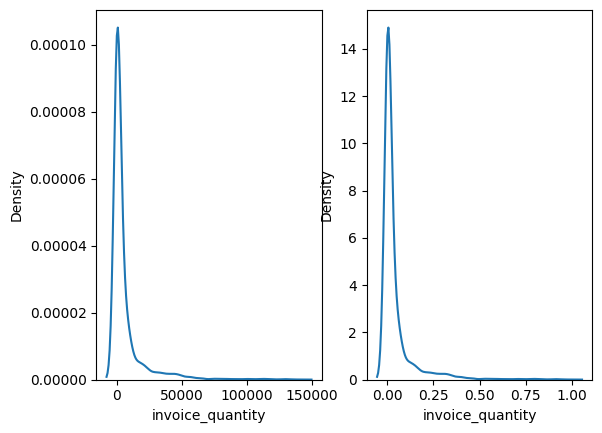

In [131]:
plt.subplot(1,2,1)
sns.kdeplot(X_train['invoice_quantity'])
plt.subplot(1,2,2)
sns.kdeplot(X_train_scaled['invoice_quantity'])
plt.show()

In [132]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


In [133]:
m1 = LogisticRegression()
m2 = DecisionTreeClassifier(random_state=42)
m3 = RandomForestClassifier(random_state=42)


In [134]:
m1.fit(X_train_scaled,Y_train)
m2.fit(X_train_scaled,Y_train)
m3.fit(X_train_scaled,Y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [135]:
ypred1 = m1.predict(X_test_scaled)
ypred2= m2.predict(X_test_scaled)
ypred3 = m3.predict(X_test_scaled)

In [136]:
from sklearn.metrics import classification_report

In [137]:
print("performace of Logistic regression")
print(classification_report(Y_test,ypred1))

performace of Logistic regression
              precision    recall  f1-score   support

           0       0.70      0.98      0.81       761
           1       0.55      0.07      0.12       348

    accuracy                           0.69      1109
   macro avg       0.62      0.52      0.46      1109
weighted avg       0.65      0.69      0.59      1109



In [138]:
print("performace of decision tree classifier")
print(classification_report(Y_test,ypred2))

performace of decision tree classifier
              precision    recall  f1-score   support

           0       0.86      0.88      0.87       761
           1       0.73      0.68      0.70       348

    accuracy                           0.82      1109
   macro avg       0.79      0.78      0.79      1109
weighted avg       0.82      0.82      0.82      1109



In [139]:
print("performace of random forest classifier")
print(classification_report(Y_test,ypred3))

performace of random forest classifier
              precision    recall  f1-score   support

           0       0.86      0.97      0.91       761
           1       0.90      0.66      0.76       348

    accuracy                           0.87      1109
   macro avg       0.88      0.81      0.83      1109
weighted avg       0.87      0.87      0.86      1109



In [155]:
pd.DataFrame([m3.feature_importances_],columns=m3.feature_names_in_)

,invoice_quantity,invoice_dollars,Freight,total_brands,total_item_quantity,days_po_to_invoice,total_item_dollars
0,0.154108,0.143445,0.149578,0.082892,0.175984,0.074875,0.219119


In [157]:
X2=X.drop(columns=['total_brands','days_po_to_invoice'])
Y2 = Y

In [158]:
X2_train,X2_test,Y2_train,Y2_test = train_test_split(X2,Y2,test_size=0.2,random_state=42)
scaler = StandardScaler()
X2_train_scaled = scaler.fit_transform(X2_train)
X2_test_scaled = scaler.transform(X2_test)

In [177]:
model3 = RandomForestClassifier(random_state=42)
model3.fit(X2_train_scaled,Y2_train)
print(classification_report(Y2_test,model3.predict(X2_test_scaled)))

              precision    recall  f1-score   support

           0       0.87      0.97      0.92       725
           1       0.93      0.71      0.81       384

    accuracy                           0.88      1109
   macro avg       0.90      0.84      0.86      1109
weighted avg       0.89      0.88      0.88      1109



In [178]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer,f1_score

In [180]:
param_grid ={
"n_estimators": [100,200, 300],
"max_depth": [None,4, 5, 6],
"min_samples_split": [2, 3, 5],
"min_samples_leaf": [1, 2, 5],
"criterion": ['gini', 'entropy']
}
scorer = make_scorer(f1_score)
grid = GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,verbose=2,n_jobs=-1,scoring=scorer)
grid.fit(X2_train_scaled,Y2_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.1s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.1s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   2.2s
[CV] END criterion=gini, max_depth=None, min_samples_leaf=1, min_samples_split=2, n_estimators=200; tot

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['gini', 'entropy'], 'max_depth': [None, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",make_scorer(f...hod='predict')
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the comput

In [186]:
print(classification_report(Y2_test,grid.predict(X2_test_scaled)))

              precision    recall  f1-score   support

           0       0.87      0.98      0.92       725
           1       0.96      0.71      0.82       384

    accuracy                           0.89      1109
   macro avg       0.91      0.85      0.87      1109
weighted avg       0.90      0.89      0.89      1109



In [187]:
grid.best_score_

np.float64(0.8002018648389194)

In [188]:
grid.best_params_

{'criterion': 'gini',
 'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 5,
 'n_estimators': 300}

In [189]:
from sklearn.metrics import confusion_matrix
confusion_matrix(grid.predict(X2_test_scaled),Y2_test)

array([[713, 110],
       [ 12, 274]])

In [185]:
confusion_matrix(model3.predict(X2_test_scaled),Y2_test)

array([[705, 110],
       [ 20, 274]])

model3 have more number of false positive (means it predits more as compared to. grid search cv model that vendor is not risky but actually it is )